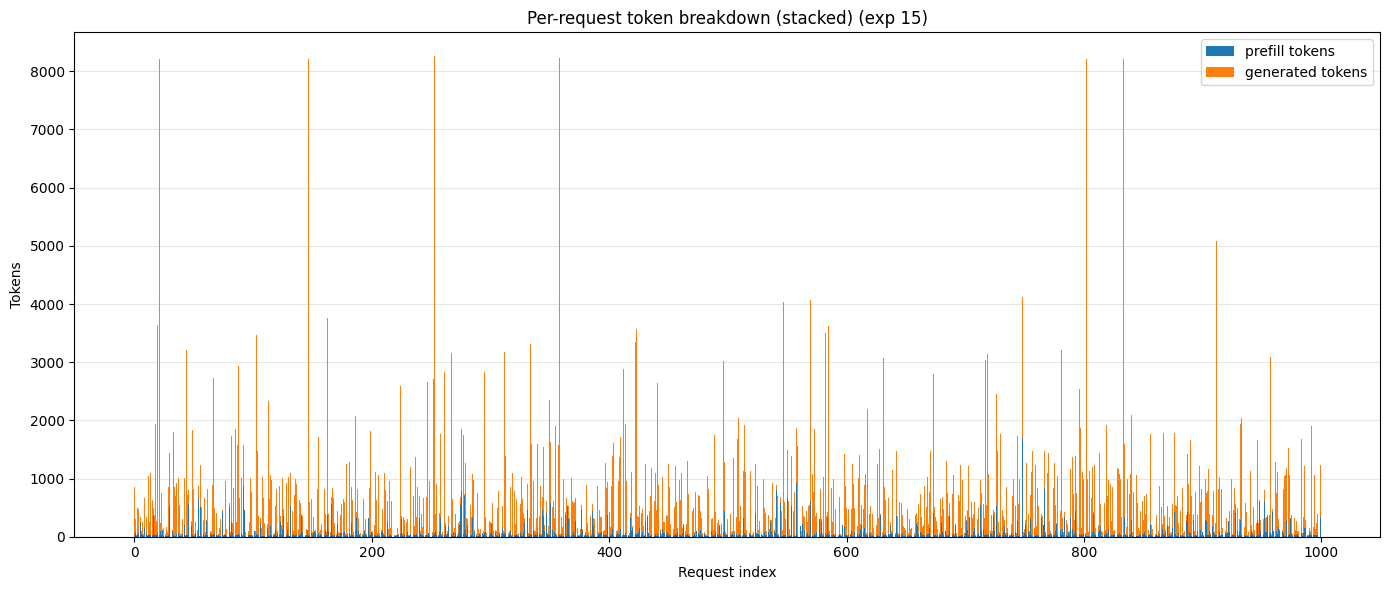

In [4]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose ONE experiment ----
exp_id = 15
# ------------------------------

# ---- plotting controls ----
max_requests_to_plot = 1000   # set None to plot all (can get slow/cluttered)

# ---- choose what to show (uncomment as needed) ----
show_prefill = True
show_generated = True
# show_prefill = True;  show_generated = False   # only prefill
# show_prefill = False; show_generated = True    # only generated
# -----------------------------------------------

df = (
    load_experiment_latencies(exp_id=exp_id)
    .sort_values("idx")
    .reset_index(drop=True)
)

# Pull columns if present
x = pd.to_numeric(df.get("idx"), errors="coerce")

prefill = None
gen = None

if show_prefill:
    prefill = pd.to_numeric(df.get("prompt_tokens"), errors="coerce")
    if "prompt_tokens" not in df.columns:
        print("WARN: prompt_tokens not found; disabling prefill plot.")
        show_prefill = False

if show_generated:
    # support either completion_tokens or output_tokens naming
    if "completion_tokens" in df.columns:
        gen = pd.to_numeric(df["completion_tokens"], errors="coerce")
    elif "output_tokens" in df.columns:
        gen = pd.to_numeric(df["output_tokens"], errors="coerce")
    else:
        print("WARN: completion_tokens/output_tokens not found; disabling generated plot.")
        show_generated = False

if not show_prefill and not show_generated:
    raise RuntimeError("Nothing to plot: both prefill and generated are disabled or missing.")

# Build mask of valid rows depending on what is enabled
mask = x.notna()
if show_prefill and prefill is not None:
    mask &= prefill.notna()
if show_generated and gen is not None:
    mask &= gen.notna()

x = x[mask].astype(int).values
prefill_vals = prefill[mask].values if (show_prefill and prefill is not None) else None
gen_vals = gen[mask].values if (show_generated and gen is not None) else None

# Trim if requested
if max_requests_to_plot is not None and len(x) > max_requests_to_plot:
    x = x[:max_requests_to_plot]
    if prefill_vals is not None:
        prefill_vals = prefill_vals[:max_requests_to_plot]
    if gen_vals is not None:
        gen_vals = gen_vals[:max_requests_to_plot]

plt.figure(figsize=(14, 6))

# Plot variants
if show_prefill and show_generated:
    # Stacked bars: prefill at bottom, generated on top
    plt.bar(x, prefill_vals, label="prefill tokens")
    plt.bar(x, gen_vals, bottom=prefill_vals, label="generated tokens")
    title = "Per-request token breakdown (stacked)"
elif show_prefill:
    plt.bar(x, prefill_vals, label="prefill tokens")
    title = "Per-request prefill tokens"
else:
    plt.bar(x, gen_vals, label="generated tokens")
    title = "Per-request generated tokens"

plt.xlabel("Request index")
plt.ylabel("Tokens")
plt.title(f"{title} (exp {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()


=== Experiment 15 length summary ===
rows: 9,999
token columns: prompt=prompt_tokens, output=completion_tokens
latency columns: e2e=end_to_end_s, ttft=MISSING, tpot=MISSING, queue=MISSING, service=server_roundtrip_s

prompt_tokens: count=9,999 mean=85.18 std=134.69 min=13 max=2571 p50=34 p90=247 p95=365 p99=626 p99.9=1053
output_tokens: count=9,999 mean=595.97 std=1066.10 min=2 max=8192 p50=274 p90=1278 p95=1869 p99=8192 p99.9=8192
total_tokens: count=9,999 mean=681.15 std=1075.56 min=18 max=10763 p50=382 p90=1379 p95=2038 p99=8214 p99.9=8487

Top 10% of requests account for 43.5% of TOTAL tokens
Top 5% of requests account for 31.5% of TOTAL tokens
Top 1% of requests account for 12.2% of TOTAL tokens
Top 0.5% of requests account for 6.2% of TOTAL tokens

CV(prompt)=1.58  CV(output)=1.79  CV(total)=1.58

=== Top 20 by total_tokens ===
 idx  prompt_tokens_norm  output_tokens_norm  total_tokens_norm  end_to_end_s  server_roundtrip_s
6235                2571                8192            

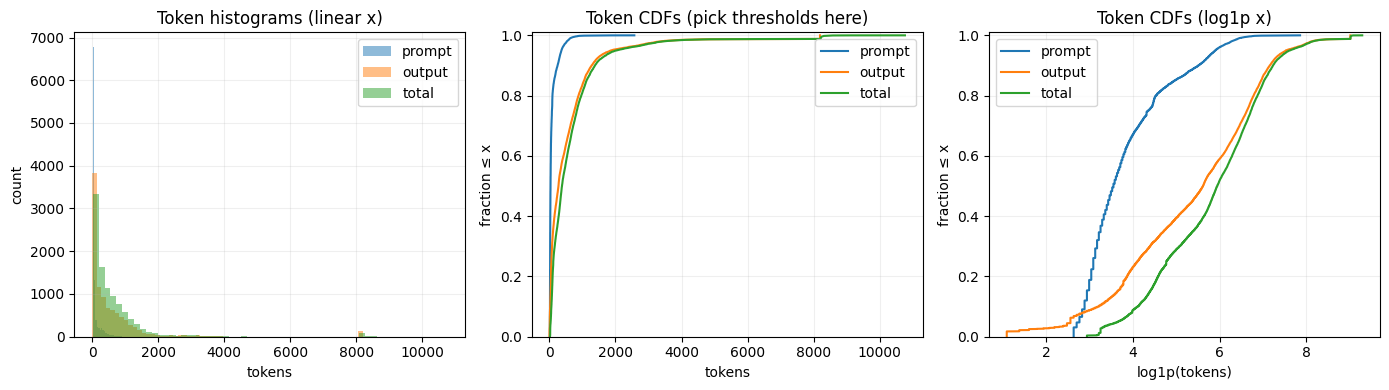

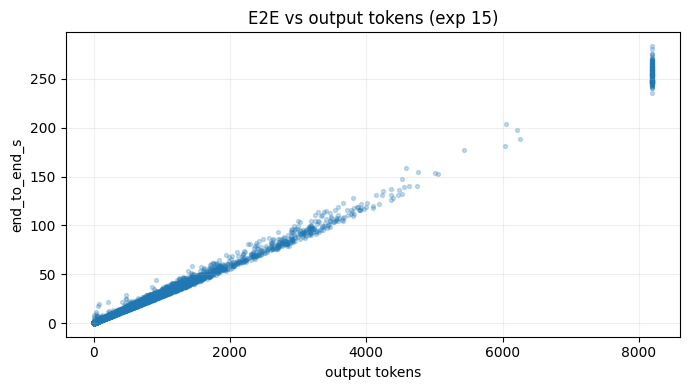

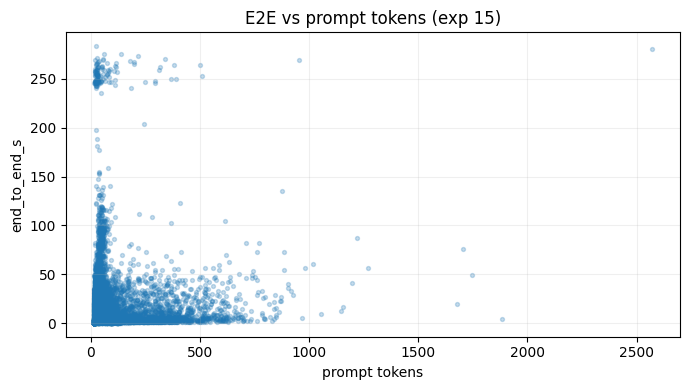

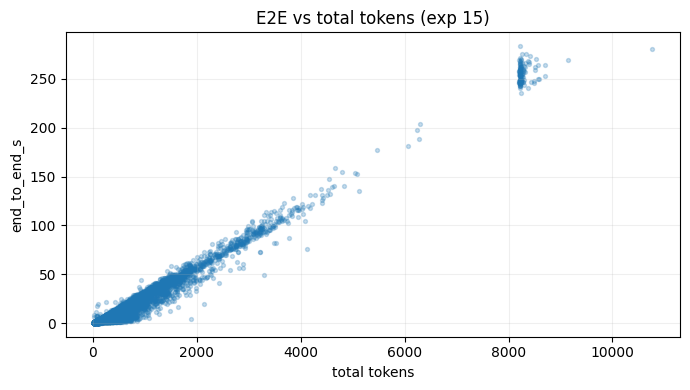

=== Design hints from this trace ===
prompt_tokens suggested cutoffs: median=34, p90=247, p99=626  (use these to define short/med/long bins)
output_tokens suggested cutoffs: median=274, p90=1278, p99=8192  (use these to define short/med/long bins)
total_tokens suggested cutoffs: median=382, p90=1379, p99=8214  (use these to define short/med/long bins)
prompt_tokens tail ratio p99/median = 18.41
output_tokens tail ratio p99/median = 29.90
total_tokens tail ratio p99/median = 21.50

If you want the next experiments to be maximally informative, consider:
- A 'pure short' workload near the median lengths (both prompt/output).
- A heavy-tail mix: e.g., 80–90% around median + 10–20% sampled from the top 1% tail.
- A sweep around the observed stability knee (your prior results suggest this is where policies diverge).


In [2]:
# Length analysis cell (self-contained)
# Goal: summarize input/output/total token distributions + how they relate to latency tails,
# to help design the next experiments (short/medium/long mixes, heavy-tail, RPS sweep points).

from experiment_analysis import load_experiment_latencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
exp_id = 15

# how much to plot (None = all)
max_points_scatter = 20000

# binning for "latency vs length" tables
n_bins = 10

# print top-K longest requests
top_k = 20

# =========================
# Helpers
# =========================
def _first_present(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _to_num(s):
    return pd.to_numeric(s, errors="coerce")

def _quantiles(series, qs=(0.5, 0.9, 0.95, 0.99, 0.999)):
    s = series.dropna()
    if len(s) == 0:
        return {}
    return {f"p{int(q*1000)/10:g}": float(np.quantile(s.values, q)) for q in qs}

def _cdf_plot(ax, data, label):
    x = np.sort(data[~np.isnan(data)])
    if len(x) == 0:
        return
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, label=label)

def _safe_int(x):
    try:
        return int(x)
    except Exception:
        return None

# =========================
# Load + normalize columns
# =========================
df = load_experiment_latencies(exp_id=exp_id).copy()

# Request index (for optional time/ordering views)
idx_col = _first_present(df, ["idx", "request_idx", "i"])
if idx_col is None:
    df["idx"] = np.arange(len(df))
    idx_col = "idx"
df[idx_col] = _to_num(df[idx_col])

# Token columns
prompt_col = _first_present(df, ["prompt_tokens", "input_tokens", "prefill_tokens"])
out_col = _first_present(df, ["completion_tokens", "output_tokens", "generated_tokens"])

if prompt_col is None and out_col is None:
    raise RuntimeError(
        "No token columns found. Expected something like prompt_tokens and completion_tokens/output_tokens."
    )

if prompt_col is None:
    df["prompt_tokens_norm"] = np.nan
else:
    df["prompt_tokens_norm"] = _to_num(df[prompt_col])

if out_col is None:
    df["output_tokens_norm"] = np.nan
else:
    df["output_tokens_norm"] = _to_num(df[out_col])

df["total_tokens_norm"] = df["prompt_tokens_norm"] + df["output_tokens_norm"]

# Latency columns (best effort)
e2e_col = _first_present(df, ["end_to_end_s", "end_to_end_latency_s", "e2e_s", "e2e_latency_s", "end_to_end_latency_seconds"])
ttft_col = _first_present(df, ["ttft_s", "ttft_seconds", "ttft_seconds_avg", "time_to_first_token_s"])
tpot_col = _first_present(df, ["tpot_s", "tpot_seconds", "tpot_seconds_avg", "time_per_output_token_s"])
queue_col = _first_present(df, ["router_queue_wait_s", "queue_wait_s", "queue_time_s", "queue_time_seconds"])
srv_col = _first_present(df, ["server_roundtrip_s", "server_round_trip_s", "service_time_s", "server_time_s"])

for c in [e2e_col, ttft_col, tpot_col, queue_col, srv_col]:
    if c is not None:
        df[c] = _to_num(df[c])

# Keep rows that have at least one length dimension
mask_len = df["prompt_tokens_norm"].notna() | df["output_tokens_norm"].notna()
df = df[mask_len].sort_values(idx_col).reset_index(drop=True)

# =========================
# Summary stats
# =========================
N = len(df)
print(f"=== Experiment {exp_id} length summary ===")
print(f"rows: {N:,}")
print(f"token columns: prompt={prompt_col or 'MISSING'}, output={out_col or 'MISSING'}")
print(f"latency columns: e2e={e2e_col or 'MISSING'}, ttft={ttft_col or 'MISSING'}, tpot={tpot_col or 'MISSING'}, queue={queue_col or 'MISSING'}, service={srv_col or 'MISSING'}")
print()

def _describe_one(name, s):
    s = s.dropna()
    if len(s) == 0:
        print(f"{name}: (no data)")
        return
    q = _quantiles(s)
    print(f"{name}: count={len(s):,} mean={s.mean():.2f} std={s.std():.2f} min={s.min():.0f} max={s.max():.0f} "
          + " ".join([f"{k}={v:.0f}" for k, v in q.items()]))

_describe_one("prompt_tokens", df["prompt_tokens_norm"])
_describe_one("output_tokens", df["output_tokens_norm"])
_describe_one("total_tokens", df["total_tokens_norm"])
print()

# Heavy-tail signals: how much of the total tokens are in the top X% requests?
def _tail_mass(s, frac=0.01):
    s = s.dropna().values
    if len(s) == 0:
        return np.nan
    s = np.sort(s)
    k = max(1, int(np.ceil(len(s) * frac)))
    return float(s[-k:].sum() / s.sum()) if s.sum() > 0 else np.nan

for frac in [0.10, 0.05, 0.01, 0.005]:
    tm = _tail_mass(df["total_tokens_norm"], frac)
    if np.isfinite(tm):
        print(f"Top {int(frac*1000)/10:g}% of requests account for {tm*100:.1f}% of TOTAL tokens")
print()

# Coefficient of variation as a quick "variance" measure
def _cv(s):
    s = s.dropna()
    if len(s) == 0 or s.mean() == 0:
        return np.nan
    return float(s.std() / s.mean())

print(f"CV(prompt)={_cv(df['prompt_tokens_norm']):.2f}  CV(output)={_cv(df['output_tokens_norm']):.2f}  CV(total)={_cv(df['total_tokens_norm']):.2f}")
print()

# =========================
# Top-K longest requests (by total tokens; ties handled)
# =========================
tmp = df.copy()
tmp["total_tokens_norm"] = _to_num(tmp["total_tokens_norm"])
top = tmp.sort_values("total_tokens_norm", ascending=False).head(top_k)

show_cols = [idx_col, "prompt_tokens_norm", "output_tokens_norm", "total_tokens_norm"]
for c in [ttft_col, tpot_col, e2e_col, queue_col, srv_col]:
    if c is not None and c not in show_cols:
        show_cols.append(c)

print(f"=== Top {top_k} by total_tokens ===")
print(top[show_cols].to_string(index=False))
print()

# =========================
# Length buckets + latency by bucket (very useful for designing mixes)
# =========================
def _bin_series(s, bins):
    s = s.dropna()
    if len(s) == 0:
        return None
    # quantile bins handle heavy-tail better than equal-width
    return pd.qcut(s, q=bins, duplicates="drop")

def _bucket_table(length_col, length_name, lat_col, lat_name):
    if lat_col is None:
        return None
    s_len = df[length_col]
    s_lat = df[lat_col]
    m = s_len.notna() & s_lat.notna()
    if m.sum() < 50:
        return None
    buckets = pd.qcut(s_len[m], q=n_bins, duplicates="drop")
    g = df.loc[m].assign(bucket=buckets).groupby("bucket", observed=True)
    out = pd.DataFrame({
        "count": g.size(),
        f"{length_name}_mean": g[length_col].mean(),
        f"{length_name}_p90": g[length_col].quantile(0.9),
        f"{lat_name}_mean": g[lat_col].mean(),
        f"{lat_name}_p95": g[lat_col].quantile(0.95),
        f"{lat_name}_p99": g[lat_col].quantile(0.99),
    }).reset_index()
    return out

tables = []
if prompt_col is not None and ttft_col is not None:
    t = _bucket_table("prompt_tokens_norm", "prompt", ttft_col, "ttft")
    if t is not None:
        tables.append(("TTFT vs prompt length (quantile buckets)", t))
if out_col is not None and tpot_col is not None:
    t = _bucket_table("output_tokens_norm", "output", tpot_col, "tpot")
    if t is not None:
        tables.append(("TPOT vs output length (quantile buckets)", t))
if (prompt_col is not None or out_col is not None) and e2e_col is not None:
    t = _bucket_table("total_tokens_norm", "total", e2e_col, "e2e")
    if t is not None:
        tables.append(("E2E vs total tokens (quantile buckets)", t))

for name, t in tables:
    print(f"=== {name} ===")
    print(t.to_string(index=False))
    print()

# =========================
# Plots: distributions + CDFs + scatter (length ↔ latency)
# =========================
plt.figure(figsize=(14, 4))
ax1 = plt.subplot(1, 3, 1)
ax2 = plt.subplot(1, 3, 2)
ax3 = plt.subplot(1, 3, 3)

# Histograms (log x helps heavy-tail)
for col, lab in [
    ("prompt_tokens_norm", "prompt"),
    ("output_tokens_norm", "output"),
    ("total_tokens_norm", "total"),
]:
    s = df[col].dropna().values
    if len(s) == 0:
        continue
    ax1.hist(s, bins=60, alpha=0.5, label=lab)

ax1.set_title("Token histograms (linear x)")
ax1.set_xlabel("tokens")
ax1.set_ylabel("count")
ax1.legend()
ax1.grid(True, alpha=0.2)

# CDFs (great for picking cutoffs for “short/medium/long”)
for col, lab in [
    ("prompt_tokens_norm", "prompt"),
    ("output_tokens_norm", "output"),
    ("total_tokens_norm", "total"),
]:
    s = df[col].dropna().values.astype(float)
    if len(s) == 0:
        continue
    _cdf_plot(ax2, s, lab)

ax2.set_title("Token CDFs (pick thresholds here)")
ax2.set_xlabel("tokens")
ax2.set_ylabel("fraction ≤ x")
ax2.set_ylim(0, 1.01)
ax2.legend()
ax2.grid(True, alpha=0.2)

# Log-x CDF (often clearer)
for col, lab in [
    ("prompt_tokens_norm", "prompt"),
    ("output_tokens_norm", "output"),
    ("total_tokens_norm", "total"),
]:
    s = df[col].dropna().values.astype(float)
    if len(s) == 0:
        continue
    x = np.sort(s)
    y = np.arange(1, len(x) + 1) / len(x)
    ax3.plot(np.log1p(x), y, label=lab)

ax3.set_title("Token CDFs (log1p x)")
ax3.set_xlabel("log1p(tokens)")
ax3.set_ylabel("fraction ≤ x")
ax3.set_ylim(0, 1.01)
ax3.legend()
ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Scatter plots: length ↔ latency (sample if huge)
def _scatter(x, y, title, xlabel, ylabel):
    m = x.notna() & y.notna()
    if m.sum() == 0:
        print(f"(skip) {title}: no data")
        return
    xs = x[m].values
    ys = y[m].values
    if max_points_scatter is not None and len(xs) > max_points_scatter:
        take = np.random.default_rng(0).choice(len(xs), size=max_points_scatter, replace=False)
        xs, ys = xs[take], ys[take]
    plt.figure(figsize=(7, 4))
    plt.scatter(xs, ys, s=8, alpha=0.25)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

if e2e_col is not None:
    if out_col is not None:
        _scatter(df["output_tokens_norm"], df[e2e_col], f"E2E vs output tokens (exp {exp_id})", "output tokens", f"{e2e_col}")
    if prompt_col is not None:
        _scatter(df["prompt_tokens_norm"], df[e2e_col], f"E2E vs prompt tokens (exp {exp_id})", "prompt tokens", f"{e2e_col}")
    _scatter(df["total_tokens_norm"], df[e2e_col], f"E2E vs total tokens (exp {exp_id})", "total tokens", f"{e2e_col}")

if ttft_col is not None and prompt_col is not None:
    _scatter(df["prompt_tokens_norm"], df[ttft_col], f"TTFT vs prompt tokens (exp {exp_id})", "prompt tokens", f"{ttft_col}")

if tpot_col is not None and out_col is not None:
    _scatter(df["output_tokens_norm"], df[tpot_col], f"TPOT vs output tokens (exp {exp_id})", "output tokens", f"{tpot_col}")

# =========================
# Experiment design hints (computed from THIS experiment)
# =========================
print("=== Design hints from this trace ===")

# Suggested thresholds for short/medium/long buckets based on quantiles
def _suggest_thresholds(name, s):
    s = s.dropna()
    if len(s) == 0:
        return
    qs = [0.5, 0.9, 0.99]
    vals = [int(np.quantile(s.values, q)) for q in qs]
    print(f"{name} suggested cutoffs: median={vals[0]}, p90={vals[1]}, p99={vals[2]}  (use these to define short/med/long bins)")

_suggest_thresholds("prompt_tokens", df["prompt_tokens_norm"])
_suggest_thresholds("output_tokens", df["output_tokens_norm"])
_suggest_thresholds("total_tokens", df["total_tokens_norm"])

# A rough “tail risk” indicator: how different is p99 from median?
def _tail_ratio(name, s):
    s = s.dropna()
    if len(s) == 0:
        return
    med = np.quantile(s.values, 0.5)
    p99 = np.quantile(s.values, 0.99)
    if med > 0:
        print(f"{name} tail ratio p99/median = {p99/med:.2f}")

_tail_ratio("prompt_tokens", df["prompt_tokens_norm"])
_tail_ratio("output_tokens", df["output_tokens_norm"])
_tail_ratio("total_tokens", df["total_tokens_norm"])

print("\nIf you want the next experiments to be maximally informative, consider:")
print("- A 'pure short' workload near the median lengths (both prompt/output).")
print("- A heavy-tail mix: e.g., 80–90% around median + 10–20% sampled from the top 1% tail.")
print("- A sweep around the observed stability knee (your prior results suggest this is where policies diverge).")


=== Exp 15 length-only report ===
rows: 9,999
prompt_col=prompt_tokens   output_col=completion_tokens

=== Length signature (compact) ===
 exp_id  prompt_p50  prompt_p90  prompt_p99  prompt_max  prompt_cv  prompt_tail1pct_mass  prompt_gini  output_p50  output_p90  output_p99  output_max  output_cv  output_tail1pct_mass  output_gini  total_p50  total_p90  total_p99  total_max  total_cv  total_tail1pct_mass  total_gini
     15        34.0       247.0       626.0      2571.0   1.581231              0.097996     0.600234       274.0      1278.0      8192.0      8192.0    1.78885              0.137471     0.649472      382.0     1379.2    8214.02    10763.0  1.579033              0.12211    0.585664

=== Length signature (full dict; copy/paste) ===
{'exp_id': 15, 'prompt_count': 9999, 'prompt_mean': 85.180018, 'prompt_cv': 1.581231, 'prompt_p50': 34.0, 'prompt_p90': 247.0, 'prompt_p95': 365.0, 'prompt_p99': 626.0, 'prompt_p999': 1053.184, 'prompt_max': 2571.0, 'prompt_tail1pct_mass': 0.0979

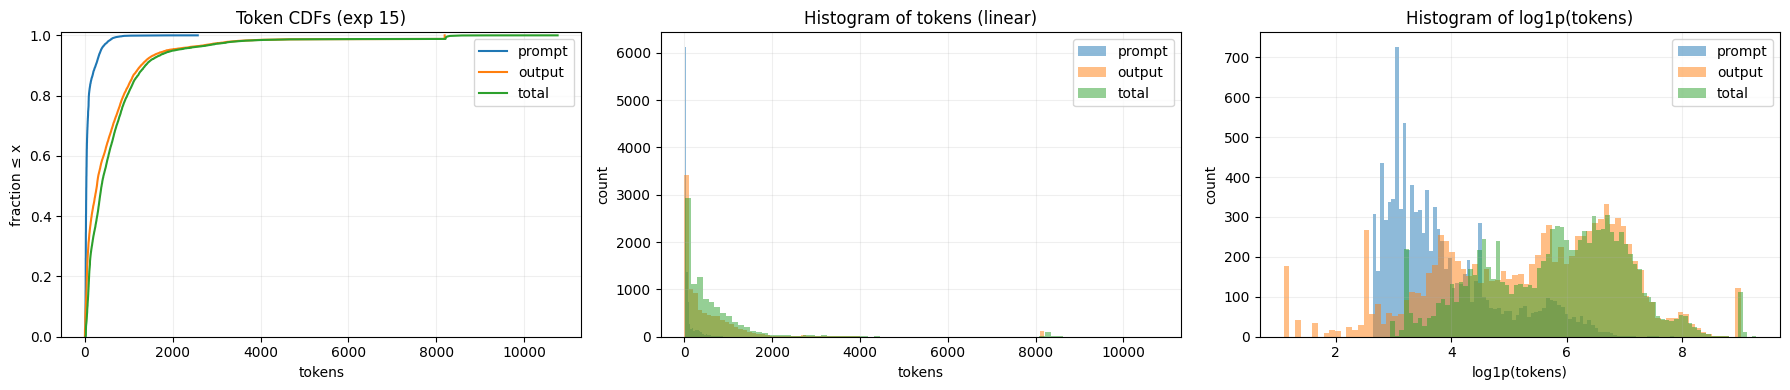

=== Suggested length bins (portable across experiments) ===
prompt suggested bins: short<=p50(34), medium<=p90(247), long<=p99(626), tail>p99
output suggested bins: short<=p50(274), medium<=p90(1278), long<=p99(8192), tail>p99
total suggested bins: short<=p50(382), medium<=p90(1379), long<=p99(8214), tail>p99


In [5]:
# Length-metrics-only analysis cell (self-contained)
# Purpose: produce length stats that are comparable across experiments,
# and emit a compact "length signature" you can paste into tables/notes.
# UPDATE: includes BOTH real (linear) histogram and log1p histogram.

from experiment_analysis import load_experiment_latencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Config
# =========================
exp_id = 15

# plotting / reporting knobs
hist_bins = 80
top_k = 20
show_plots = True

# =========================
# Helpers
# =========================
def _first_present(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _to_num(x):
    return pd.to_numeric(x, errors="coerce")

def _q(s, q):
    s = s.dropna().values
    if len(s) == 0:
        return np.nan
    return float(np.quantile(s, q))

def _cv(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    m = s.mean()
    return float(s.std() / m) if m != 0 else np.nan

def _tail_mass(s, frac):
    """Fraction of total mass contributed by the top frac of samples."""
    v = s.dropna().values
    if len(v) == 0:
        return np.nan
    v = np.sort(v)
    k = max(1, int(np.ceil(len(v) * frac)))
    top = v[-k:]
    denom = v.sum()
    return float(top.sum() / denom) if denom > 0 else np.nan

def _gini(s):
    """Gini coefficient as a single-number inequality / heavy-tail indicator."""
    v = s.dropna().values.astype(float)
    if len(v) == 0:
        return np.nan
    v = np.sort(v)
    if v.sum() == 0:
        return 0.0
    n = len(v)
    i = np.arange(1, n + 1)
    return float((2.0 * np.sum(i * v) / (n * np.sum(v))) - (n + 1) / n)

def _length_signature(s, name):
    """Compact, comparable summary across experiments."""
    return {
        f"{name}_count": int(s.notna().sum()),
        f"{name}_mean": float(s.mean()) if s.notna().any() else np.nan,
        f"{name}_cv": _cv(s),
        f"{name}_p50": _q(s, 0.50),
        f"{name}_p90": _q(s, 0.90),
        f"{name}_p95": _q(s, 0.95),
        f"{name}_p99": _q(s, 0.99),
        f"{name}_p999": _q(s, 0.999),
        f"{name}_max": float(s.max()) if s.notna().any() else np.nan,
        f"{name}_tail1pct_mass": _tail_mass(s, 0.01),
        f"{name}_tail5pct_mass": _tail_mass(s, 0.05),
        f"{name}_gini": _gini(s),
    }

def _cdf_plot(ax, s, label):
    v = s.dropna().values.astype(float)
    if len(v) == 0:
        return
    v = np.sort(v)
    y = np.arange(1, len(v) + 1) / len(v)
    ax.plot(v, y, label=label)

# =========================
# Load + normalize length columns
# =========================
df = load_experiment_latencies(exp_id=exp_id).copy()

idx_col = _first_present(df, ["idx", "request_idx", "i"])
if idx_col is None:
    df["idx"] = np.arange(len(df))
    idx_col = "idx"
df[idx_col] = _to_num(df[idx_col])

prompt_col = _first_present(df, ["prompt_tokens", "input_tokens", "prefill_tokens"])
out_col    = _first_present(df, ["completion_tokens", "output_tokens", "generated_tokens"])

if prompt_col is None and out_col is None:
    raise RuntimeError(
        "No length columns found. Need prompt_tokens/input_tokens/prefill_tokens "
        "and/or completion_tokens/output_tokens/generated_tokens."
    )

df["prompt_tokens_len"] = _to_num(df[prompt_col]) if prompt_col else np.nan
df["output_tokens_len"] = _to_num(df[out_col]) if out_col else np.nan

# total is defined when at least one exists (missing treated as 0 for summation clarity)
p = df["prompt_tokens_len"].fillna(0)
o = df["output_tokens_len"].fillna(0)
df["total_tokens_len"] = p + o

# Keep rows where either prompt or output was present
mask = df["prompt_tokens_len"].notna() | df["output_tokens_len"].notna()
df = df[mask].reset_index(drop=True)

print(f"=== Exp {exp_id} length-only report ===")
print(f"rows: {len(df):,}")
print(f"prompt_col={prompt_col or 'MISSING'}   output_col={out_col or 'MISSING'}")
print()

# =========================
# Length signature (single-row dataframe)
# =========================
sig = {"exp_id": exp_id}
sig.update(_length_signature(df["prompt_tokens_len"], "prompt"))
sig.update(_length_signature(df["output_tokens_len"], "output"))
sig.update(_length_signature(df["total_tokens_len"], "total"))

sig_df = pd.DataFrame([sig])

compact_cols = [
    "exp_id",
    "prompt_p50","prompt_p90","prompt_p99","prompt_max","prompt_cv","prompt_tail1pct_mass","prompt_gini",
    "output_p50","output_p90","output_p99","output_max","output_cv","output_tail1pct_mass","output_gini",
    "total_p50","total_p90","total_p99","total_max","total_cv","total_tail1pct_mass","total_gini",
]
print("=== Length signature (compact) ===")
print(sig_df[compact_cols].to_string(index=False))
print()

print("=== Length signature (full dict; copy/paste) ===")
print({k: (round(v, 6) if isinstance(v, float) and np.isfinite(v) else v) for k, v in sig.items()})
print()

# =========================
# Top-K longest (by total)
# =========================
top = df.sort_values("total_tokens_len", ascending=False).head(top_k)[
    [idx_col, "prompt_tokens_len", "output_tokens_len", "total_tokens_len"]
]
print(f"=== Top {top_k} longest requests (by total tokens) ===")
print(top.to_string(index=False))
print()

# =========================
# If outputs are fixed (like 8192), verify & quantify drift
# =========================
if out_col is not None and df["output_tokens_len"].notna().any():
    out_nonan = df["output_tokens_len"].dropna()
    uniq = out_nonan.nunique()
    if uniq <= 20:
        print(f"Output tokens unique values (n={uniq}): {sorted(out_nonan.unique().tolist())[:20]}")
    else:
        print(f"Output tokens unique values: {uniq} (showing min/median/max)")
        print(f"min={out_nonan.min():.0f}  median={_q(out_nonan,0.5):.0f}  max={out_nonan.max():.0f}")
    print()

# =========================
# Plots: CDF + REAL histogram + log1p histogram
# =========================
if show_plots:
    plt.figure(figsize=(18, 4))

    # 1) CDF
    ax1 = plt.subplot(1, 3, 1)
    for col, label in [("prompt_tokens_len","prompt"), ("output_tokens_len","output"), ("total_tokens_len","total")]:
        if df[col].notna().any():
            _cdf_plot(ax1, df[col], label)
    ax1.set_title(f"Token CDFs (exp {exp_id})")
    ax1.set_xlabel("tokens")
    ax1.set_ylabel("fraction ≤ x")
    ax1.set_ylim(0, 1.01)
    ax1.grid(True, alpha=0.2)
    ax1.legend()

    # 2) REAL histogram (linear tokens)
    ax2 = plt.subplot(1, 3, 2)
    for col, label in [("prompt_tokens_len","prompt"), ("output_tokens_len","output"), ("total_tokens_len","total")]:
        v = df[col].dropna().values.astype(float)
        if len(v) == 0:
            continue
        ax2.hist(v, bins=hist_bins, alpha=0.5, label=label)
    ax2.set_title("Histogram of tokens (linear)")
    ax2.set_xlabel("tokens")
    ax2.set_ylabel("count")
    ax2.grid(True, alpha=0.2)
    ax2.legend()

    # 3) log1p histogram (heavy-tail friendly)
    ax3 = plt.subplot(1, 3, 3)
    for col, label in [("prompt_tokens_len","prompt"), ("output_tokens_len","output"), ("total_tokens_len","total")]:
        v = df[col].dropna().values.astype(float)
        if len(v) == 0:
            continue
        ax3.hist(np.log1p(v), bins=hist_bins, alpha=0.5, label=label)
    ax3.set_title("Histogram of log1p(tokens)")
    ax3.set_xlabel("log1p(tokens)")
    ax3.set_ylabel("count")
    ax3.grid(True, alpha=0.2)
    ax3.legend()

    plt.tight_layout()
    plt.show()

# =========================
# Experiment-design cut points (derived from THIS exp)
# =========================
def _suggest_bins(s, name):
    s = s.dropna()
    if len(s) == 0:
        return
    p50 = _q(s, 0.50)
    p90 = _q(s, 0.90)
    p99 = _q(s, 0.99)
    print(f"{name} suggested bins: short<=p50({p50:.0f}), medium<=p90({p90:.0f}), long<=p99({p99:.0f}), tail>p99")

print("=== Suggested length bins (portable across experiments) ===")
_suggest_bins(df["prompt_tokens_len"], "prompt")
_suggest_bins(df["output_tokens_len"], "output")
_suggest_bins(df["total_tokens_len"], "total")
